In [21]:
%pip install -r ../requirements.txt

  Using cached argparse-1.4.0-py2.py3-none-any.whl.metadata (2.8 kB)
Using cached argparse-1.4.0-py2.py3-none-any.whl (23 kB)

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [22]:
import os
import csv
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torchvision.io import read_image
from torchvision import models
from torchvision.transforms import v2 as transforms
from torch.utils.data import Dataset, SubsetRandomSampler
from safetensors.torch import save_model, load_model
import torchvision.transforms.functional as F

In [23]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [24]:
class SquarePad:
    def __call__(self, image):
        c, h, w = image.size()
        max_wh = np.max([w, h])
        hp = (max_wh - w) // 2 + max_wh // 10
        vp = (max_wh - h) // 2 + max_wh // 10
        padding = (hp, vp, hp, vp)
        return F.pad(image, padding, 1, 'constant')

def image_transform(test=False):
    # normalize = transforms.Normalize(
    #     mean=[0.4914, 0.4822, 0.4465],
    #     std=[0.2023, 0.1994, 0.2010],
    # )
    mid_transforms = [
    ] if test else [
        # transforms.RandomHorizontalFlip(),
        # transforms.RandomVerticalFlip(),
        transforms.RandomAffine(degrees=10, translate=(0.1,0.1), scale=(0.9,1.1)),
        transforms.ColorJitter(),
        # transforms.GaussianBlur(5),
    ]
    return transforms.Compose([
        transforms.ConvertImageDtype(torch.float),
        transforms.RGB(),
        SquarePad(),
    ] + mid_transforms + [
        transforms.Resize((224,224)),
        # normalize,
    ])


def load_image(path):
    transform = image_transform(test=True)
    image = read_image(path)
    image = transform(image)
    return image

In [25]:
def load_paths(root_dir) -> list:
    filenames = next(os.walk(root_dir), (None, None, []))[2]
    return [os.path.join(root_dir, filename) for filename in filenames]

In [26]:
images_path = '../data/logos'

In [27]:
max_width = 0
max_height = 0
min_width = 1000
min_height = 1000
for path in load_paths(images_path)[:5]:
    image = read_image(path)
    assert image.size()[0] == 3
    width, height = image.size()[1], image.size()[2]
    max_width = max(max_width, width)
    max_height = max(max_height, height)
    min_width = min(min_width, width)
    min_height = min(min_height, height)
print(f'Min size: {min_width}x{min_height}')
print(f'Max size: {max_width}x{max_height}')

Min size: 334x553
Max size: 944x944


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0002738987..1.0000004].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000004].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.01585849..1.0000005].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.014417049..1.0000004].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000004].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000004].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.00035544703..1.0000002].


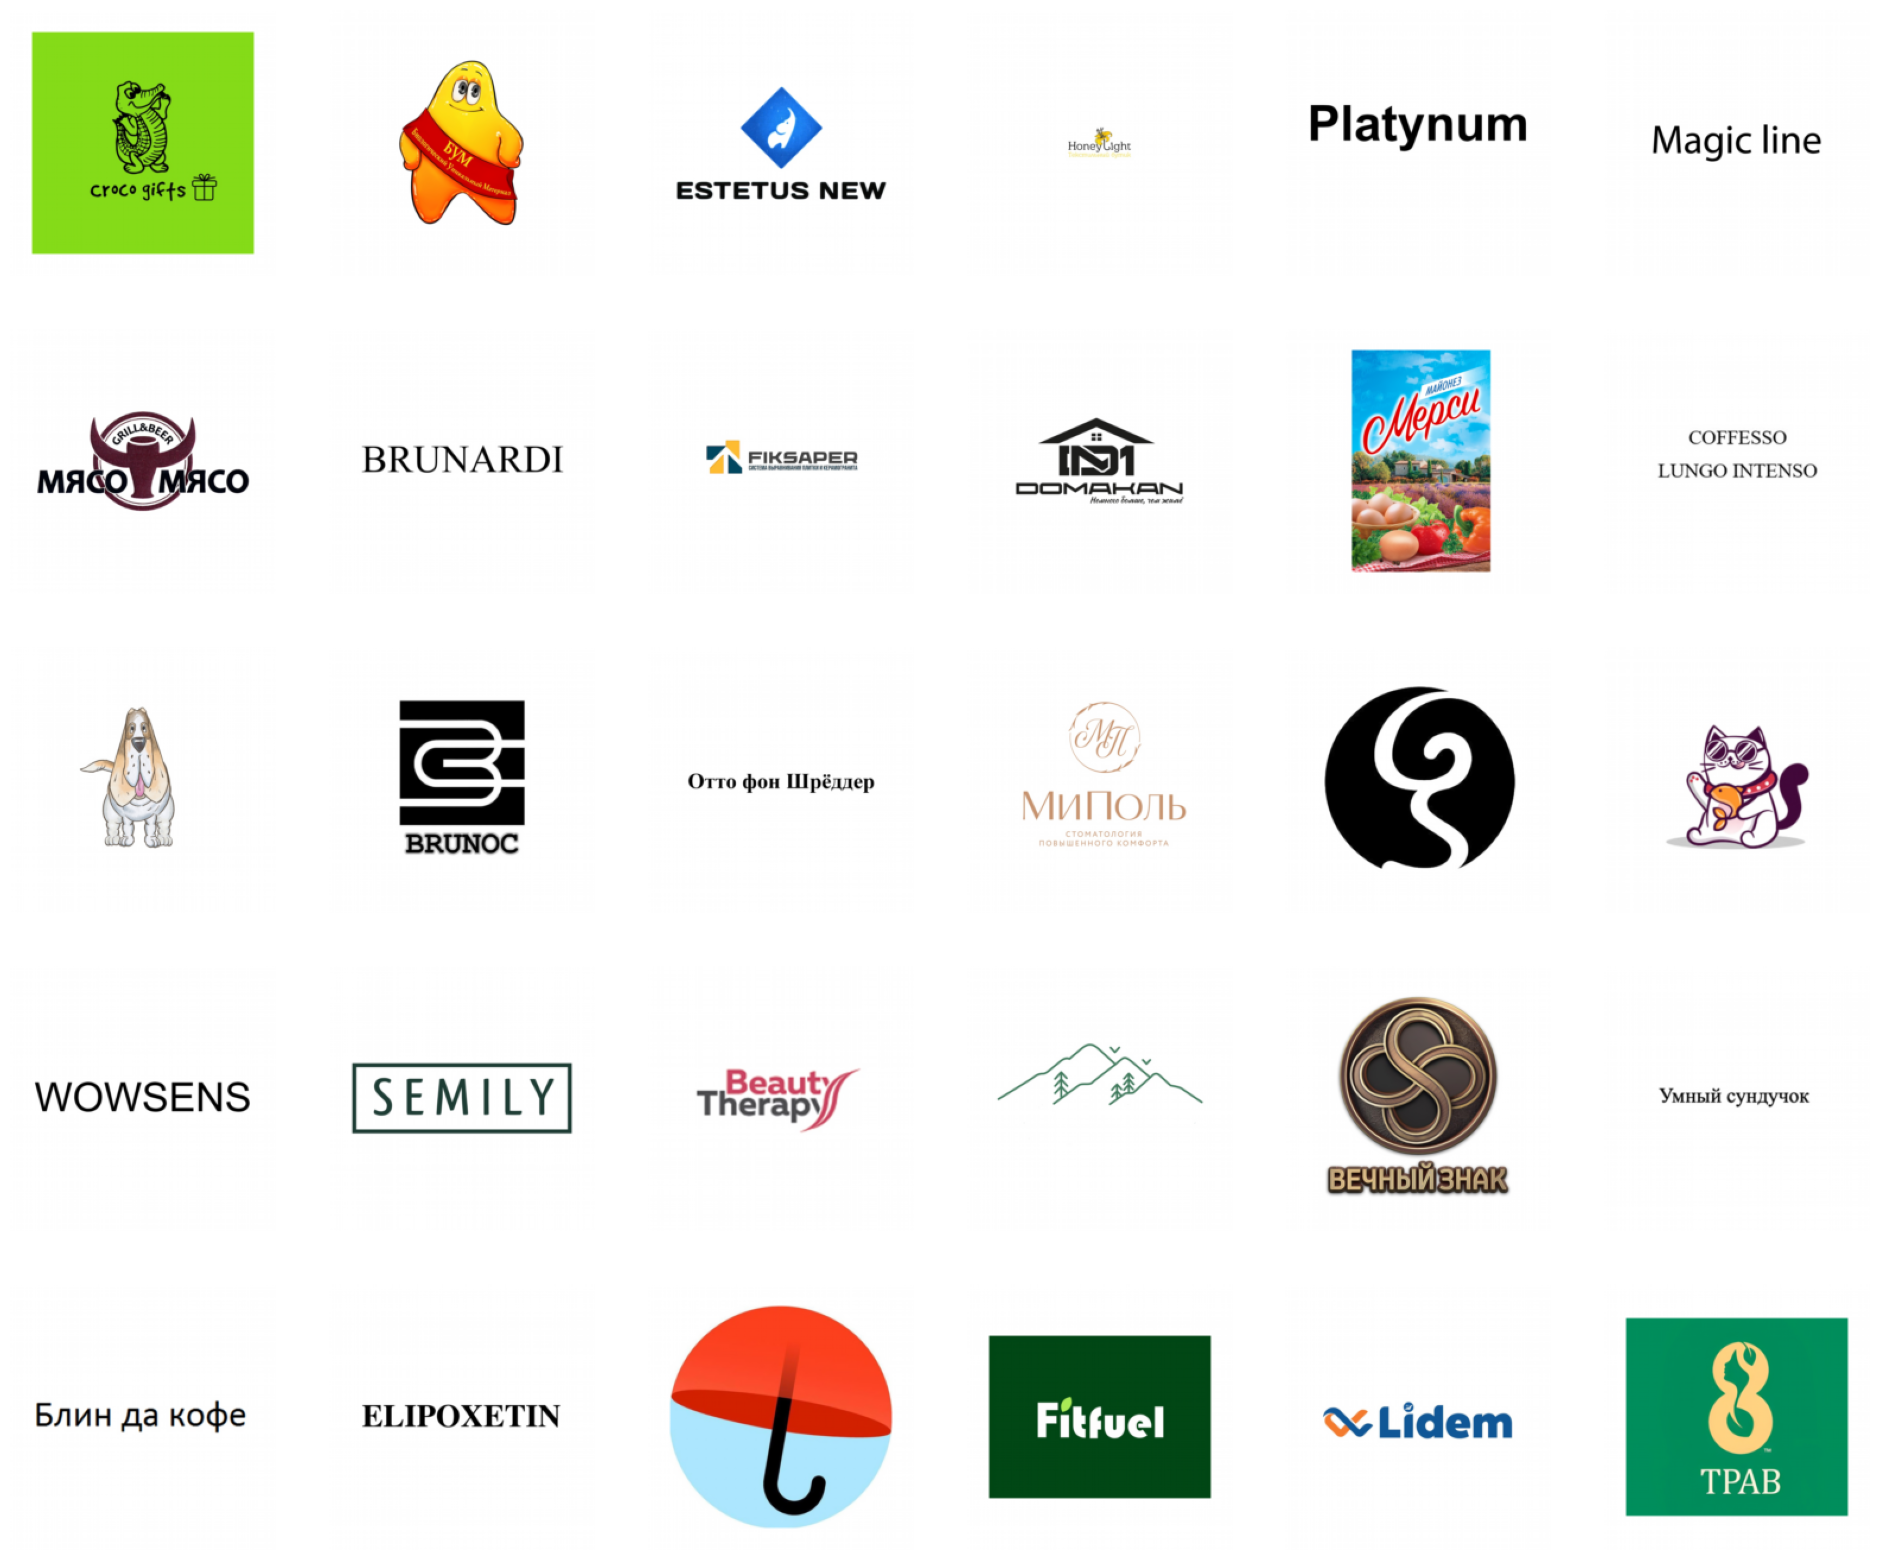

In [28]:
w, h = 6, 5
_, axs = plt.subplots(h, w, figsize=(w * 4, h * 4))

images = load_paths(images_path)

image_paths = []
np.random.shuffle(images)
image_paths.extend(images)

for i, (img_path, ax) in enumerate(zip(image_paths, axs.flatten())):
    img = load_image(img_path)
    #prediction = model(img.unsqueeze(0).to(device)).item()

    ax.imshow(img.transpose(0,1).transpose(1,2))
    ax.set_axis_off()
    #ax.set_title(f'Labelled: {label:.0f}, Predicted: {prediction:.0f}')

plt.show()

In [29]:
class LogosDataset(Dataset):
    def __init__(self, root_dir, frames_limit=None, transform=None):
        self.root = root_dir
        self.transform = transform

        self.images = []

        images = load_paths(root_dir)
        image_paths = []

        if frames_limit is None:
            image_paths = images
        else:
            np.random.shuffle(images)
            image_paths.extend(images[:frames_limit])

        self.images.extend(image_paths)

        print(f'loaded {len(self.images)} paths')

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        image = read_image(img_path)
        if self.transform:
            image = self.transform(image)
        return image, img_path

In [30]:
def data_loader(data_dir, batch_size, frames_limit=None, shuffle=True, test=False):
    transform = image_transform(test)
    dataset = LogosDataset(data_dir, frames_limit, transform)

    indices = list(range(len(dataset)))
    if shuffle:
        np.random.shuffle(indices)

    sampler = SubsetRandomSampler(indices)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, sampler=sampler)
    return loader

In [31]:
# AutoEncoder
class ModelAE(nn.Module):
    def __init__(self):
        super(ModelAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 6, kernel_size=5, stride=2, padding=0),
            nn.ReLU(),
            nn.Conv2d(6, 16, kernel_size=5, stride=2, padding=0),
            nn.ReLU(),
            nn.Conv2d(16, 64, kernel_size=5, stride=2, padding=0),
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 16, kernel_size=5, stride=2, output_padding=0),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 6, kernel_size=5, stride=2, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(6, 3, kernel_size=5, stride=2, output_padding=1),
            nn.ReLU(),
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


In [32]:
model = ModelAE()
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-8)

cuda
loaded 1000 paths
Epoch 1/5, Loss: 0.053478
Epoch 2/5, Loss: 0.040148
Epoch 3/5, Loss: 0.030541
Epoch 4/5, Loss: 0.026349
Epoch 5/5, Loss: 0.027759


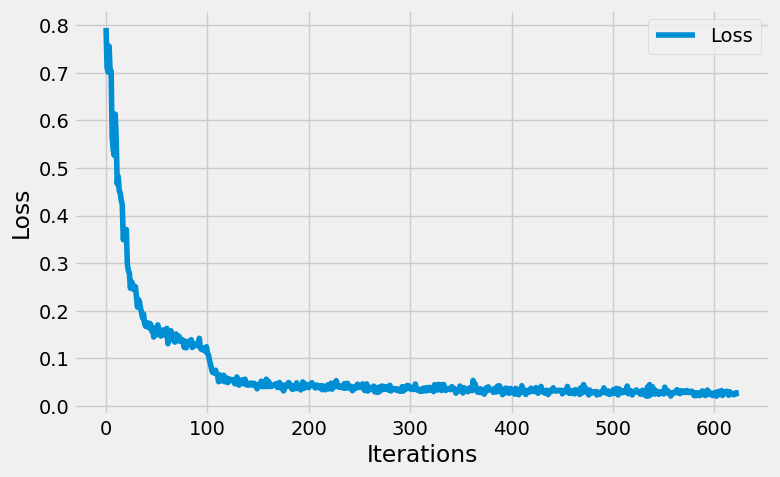

In [33]:
epochs = 5
outputs = []
losses = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model.to(device)
model.train()

loader = data_loader('../data/logos', 8)
train_loader = loader

for epoch in range(epochs):
    for images, _ in train_loader:
        images = images.to(device)
        
        reconstructed = model(images)
        loss = loss_function(reconstructed, images)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        losses.append(loss.item())
    
    outputs.append((epoch, images, reconstructed))
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f}")

plt.style.use('fivethirtyeight')
plt.figure(figsize=(8, 5))
plt.plot(losses, label='Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.031099502..1.0000004].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.06364976..1.5053663].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.06518366..1.0000002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.062539..1.4474938].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000005].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.062539..1.4853948].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.12608014..1.00000

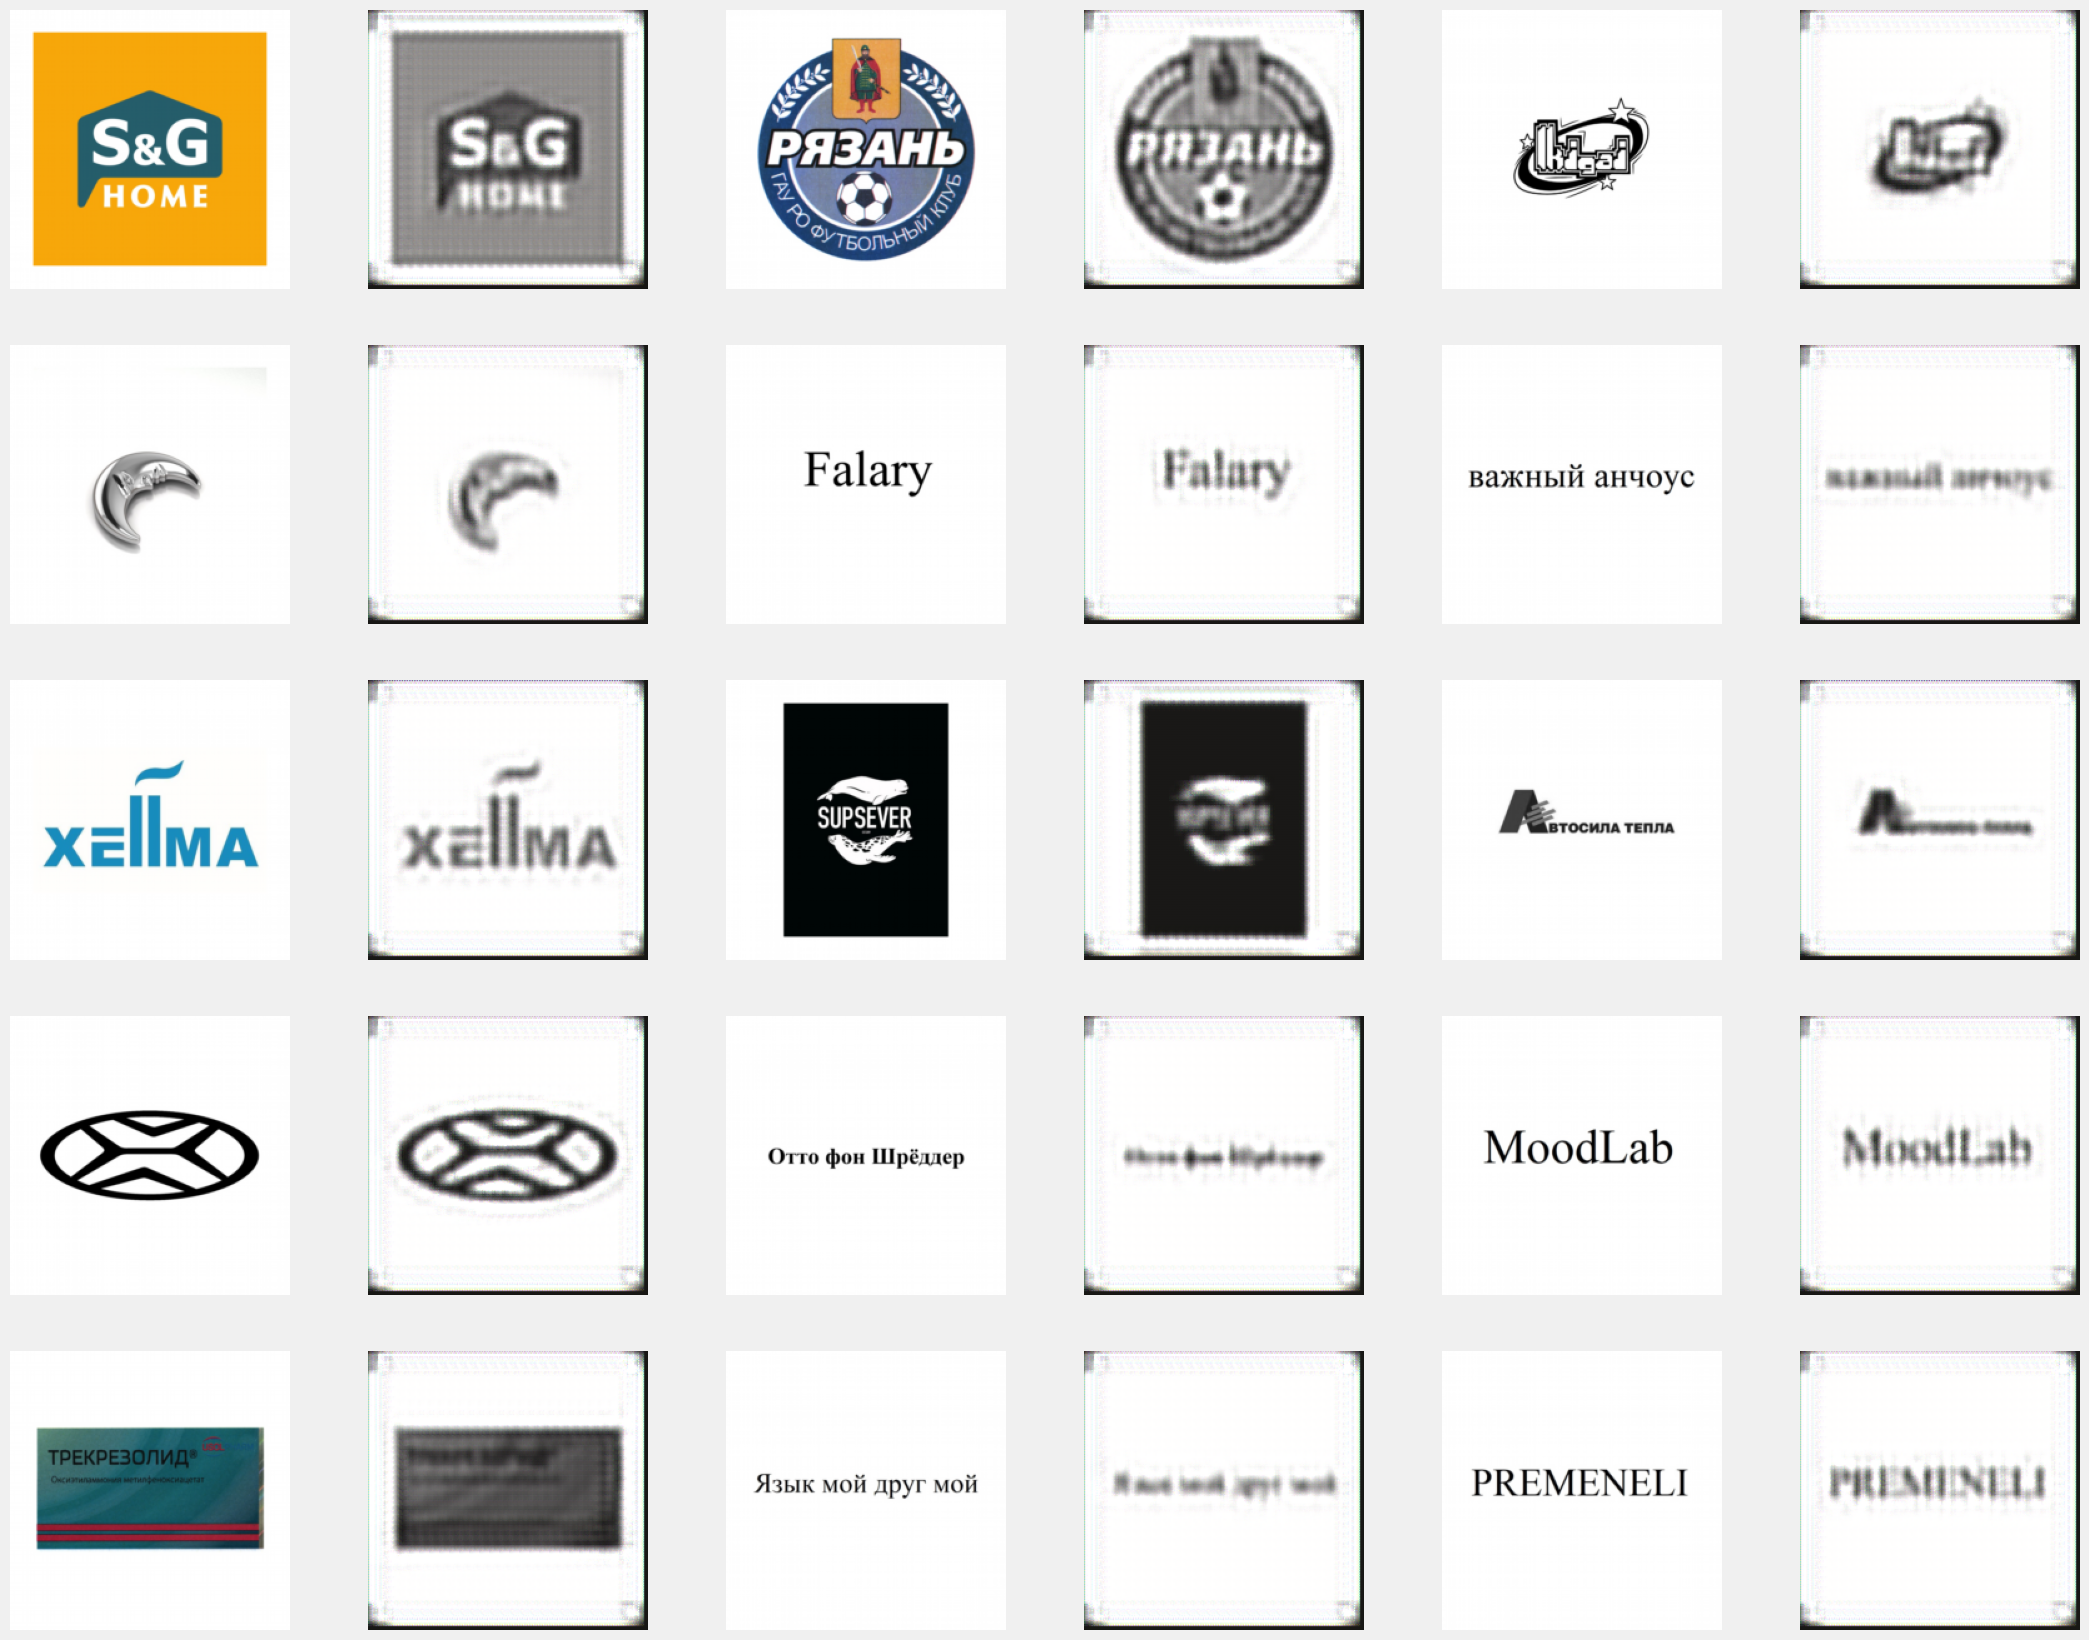

In [34]:
w, h = 6, 5
_, axs = plt.subplots(h, w, figsize=(w * 4, h * 4))

images = load_paths(images_path)

image_paths = []
np.random.shuffle(images)
image_paths.extend(images)

for i, ax in enumerate(axs.flatten()):
    img_i = i // 2
    if img_i >= len(image_paths):
        break

    img_path = image_paths[img_i]
    img = load_image(img_path)

    if i % 2 == 1:
        img = model(img.unsqueeze(0).to(device)).detach().cpu().squeeze(0)

    ax.imshow(img.transpose(0,1).transpose(1,2))
    ax.set_axis_off()
    #ax.set_title(f'Labelled: {label:.0f}, Predicted: {prediction:.0f}')

plt.show()

/home/nertsal/Innopolis/Industrial/VisualAutoencoder/.direnv/python-3.11/lib/python3.11/site-packages/torch/nn/modules/loss.py:634: UserWarning: Using a target size (torch.Size([64, 25, 25])) that is different to the input size (torch.Size([1, 64, 25, 25])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/home/nertsal/Innopolis/Industrial/VisualAutoencoder/.direnv/python-3.11/lib/python3.11/site-packages/torch/nn/modules/loss.py:634: UserWarning: Using a target size (torch.Size([5, 64, 25, 25])) that is different to the input size (torch.Size([1, 64, 25, 25])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000004].
Clipping inpu

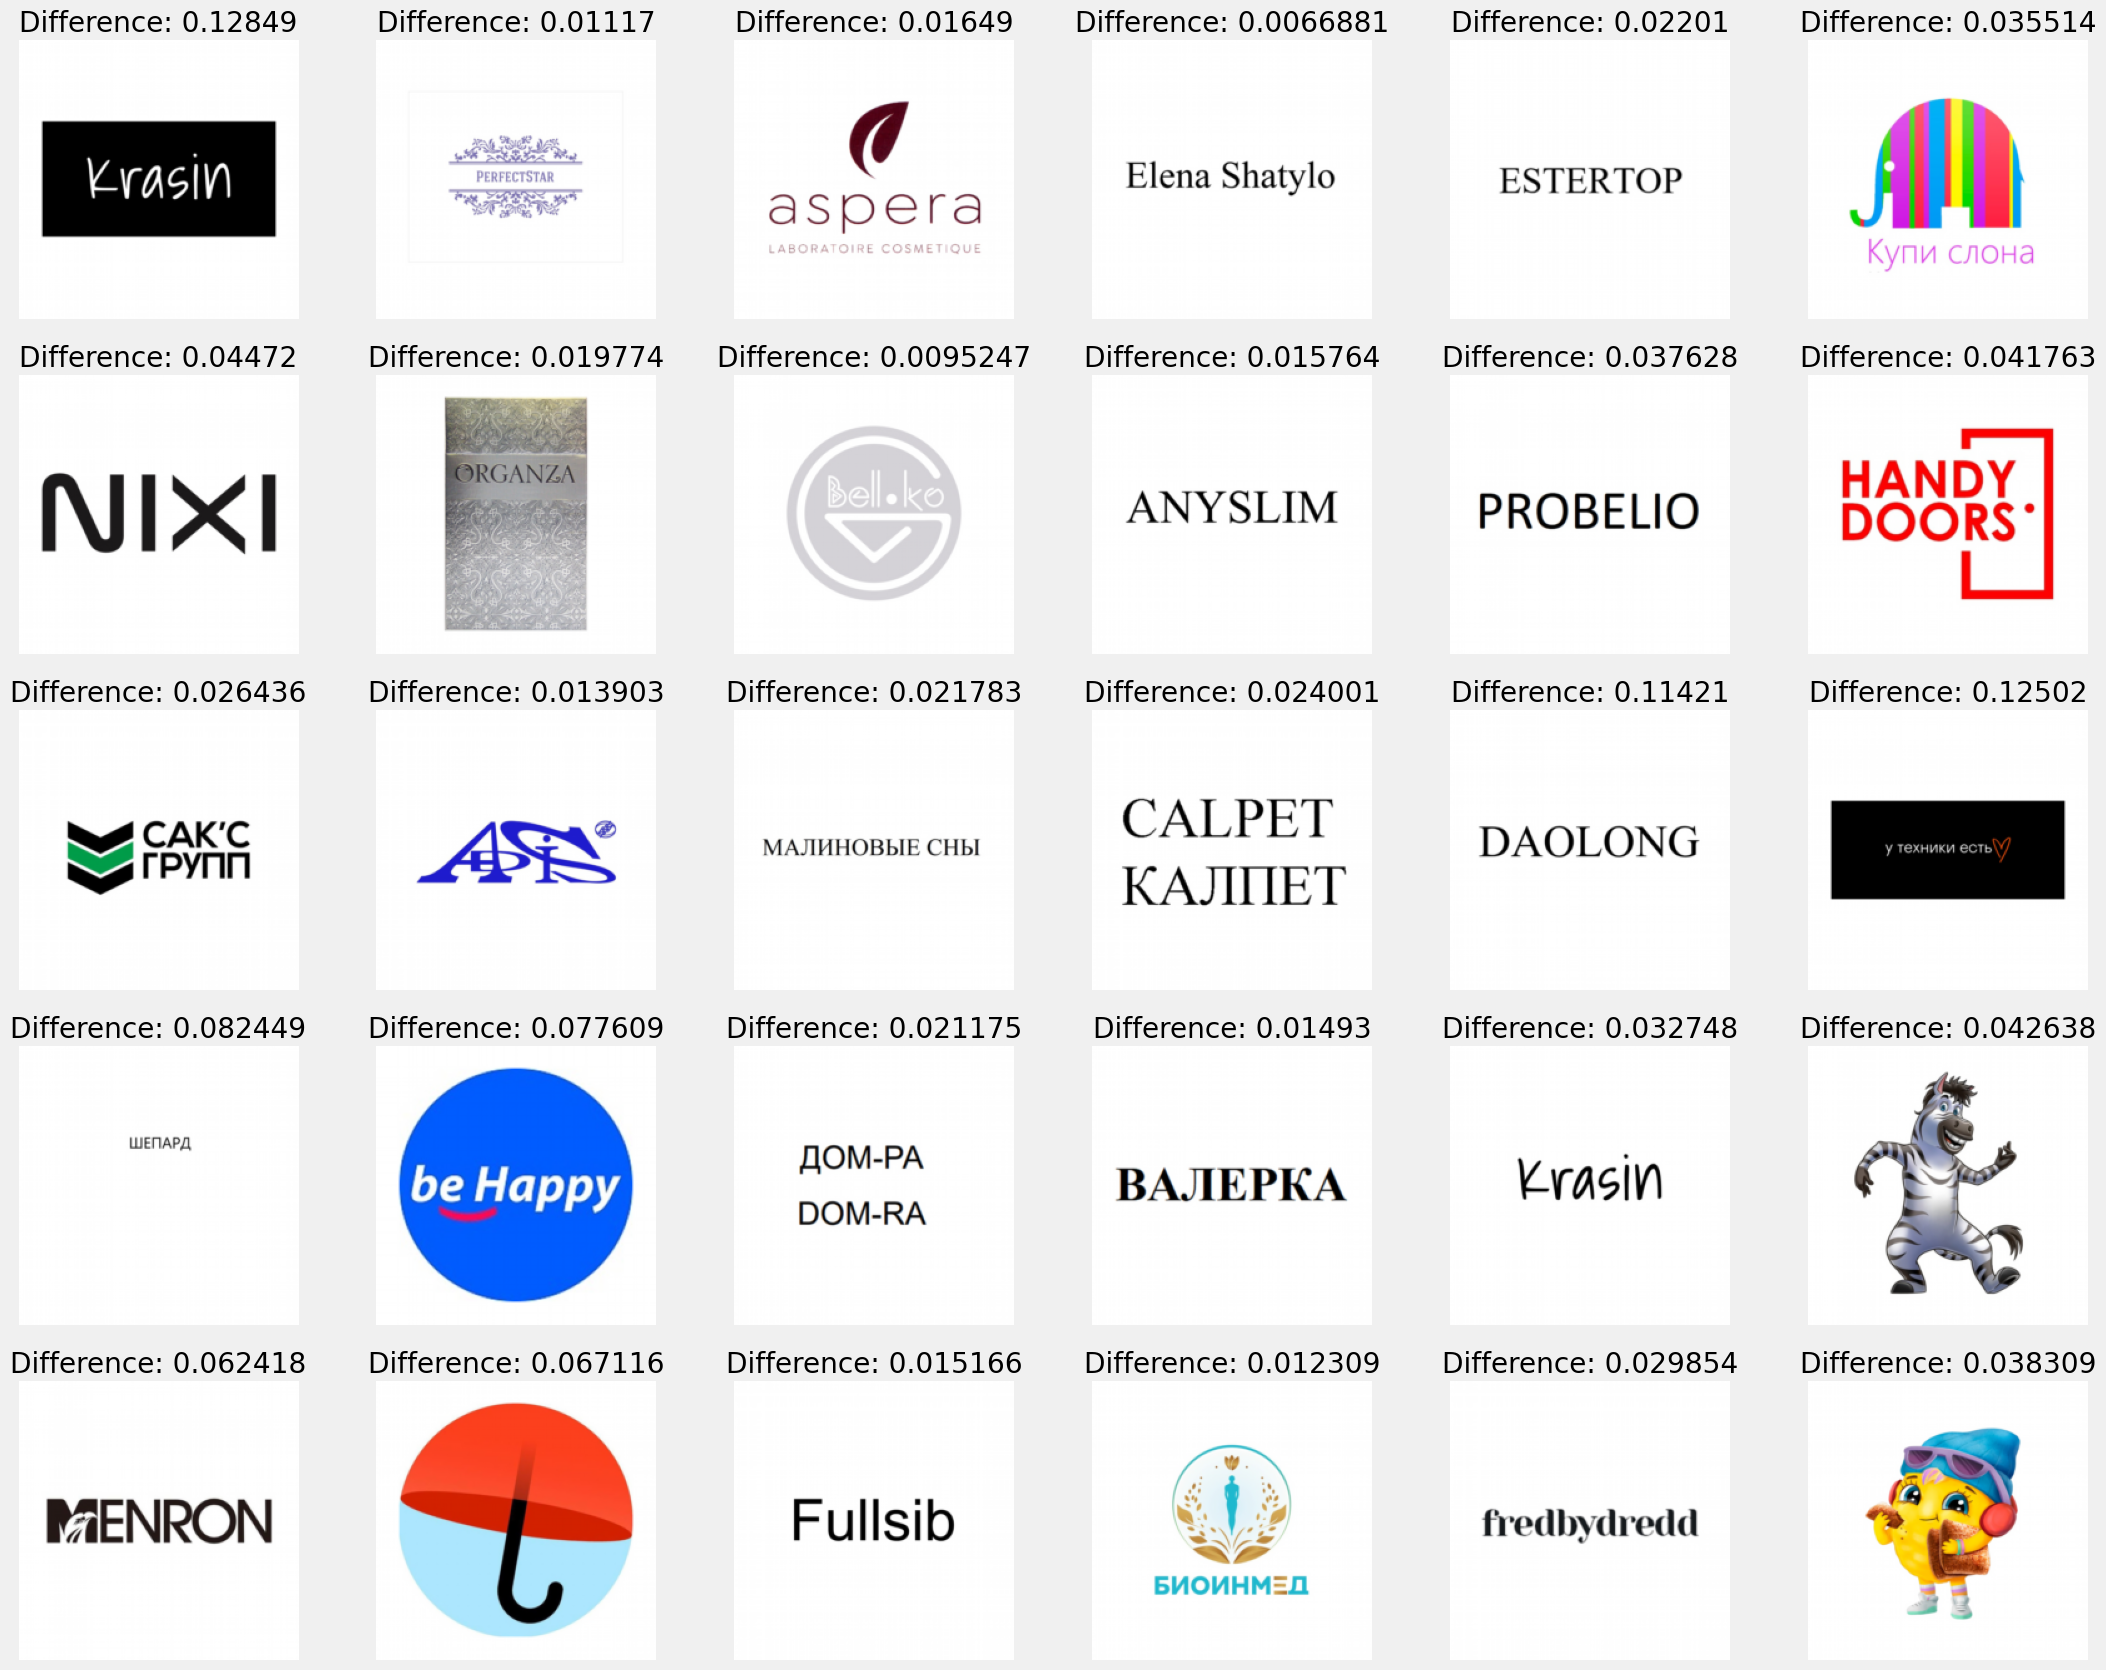

In [ ]:
w, h = 6, 5
_, axs = plt.subplots(h, w, figsize=(w * 4, h * 4))

images = load_paths(images_path)

image_paths = []
np.random.shuffle(images)
image_paths.extend(images)

model.eval()
for i, ax in enumerate(axs.flatten()):
    img_path = image_paths[i]
    img = load_image(img_path)

    encoded = model.encoder(img.unsqueeze(0).to(device)).detach()
    encoded_arr = model.encoder(torch.stack([img,img,img,img,load_image(image_paths[i+1])]).to(device)).detach()

    #losses = [nn.MSELoss()(encoded, other) for other in encoded_arr]
    #print(losses)

    loss = nn.MSELoss()(encoded, encoded_arr)
    ax.imshow(img.transpose(0,1).transpose(1,2))
    ax.set_axis_off()
    ax.set_title(f'Difference: {loss:.5}')

plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.12738046..1.0000005].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.109627314..1.0000005].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0037041437..1.0000005].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.010369201..1.0000005].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000005].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2174717..1.0000005].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.19951493..1

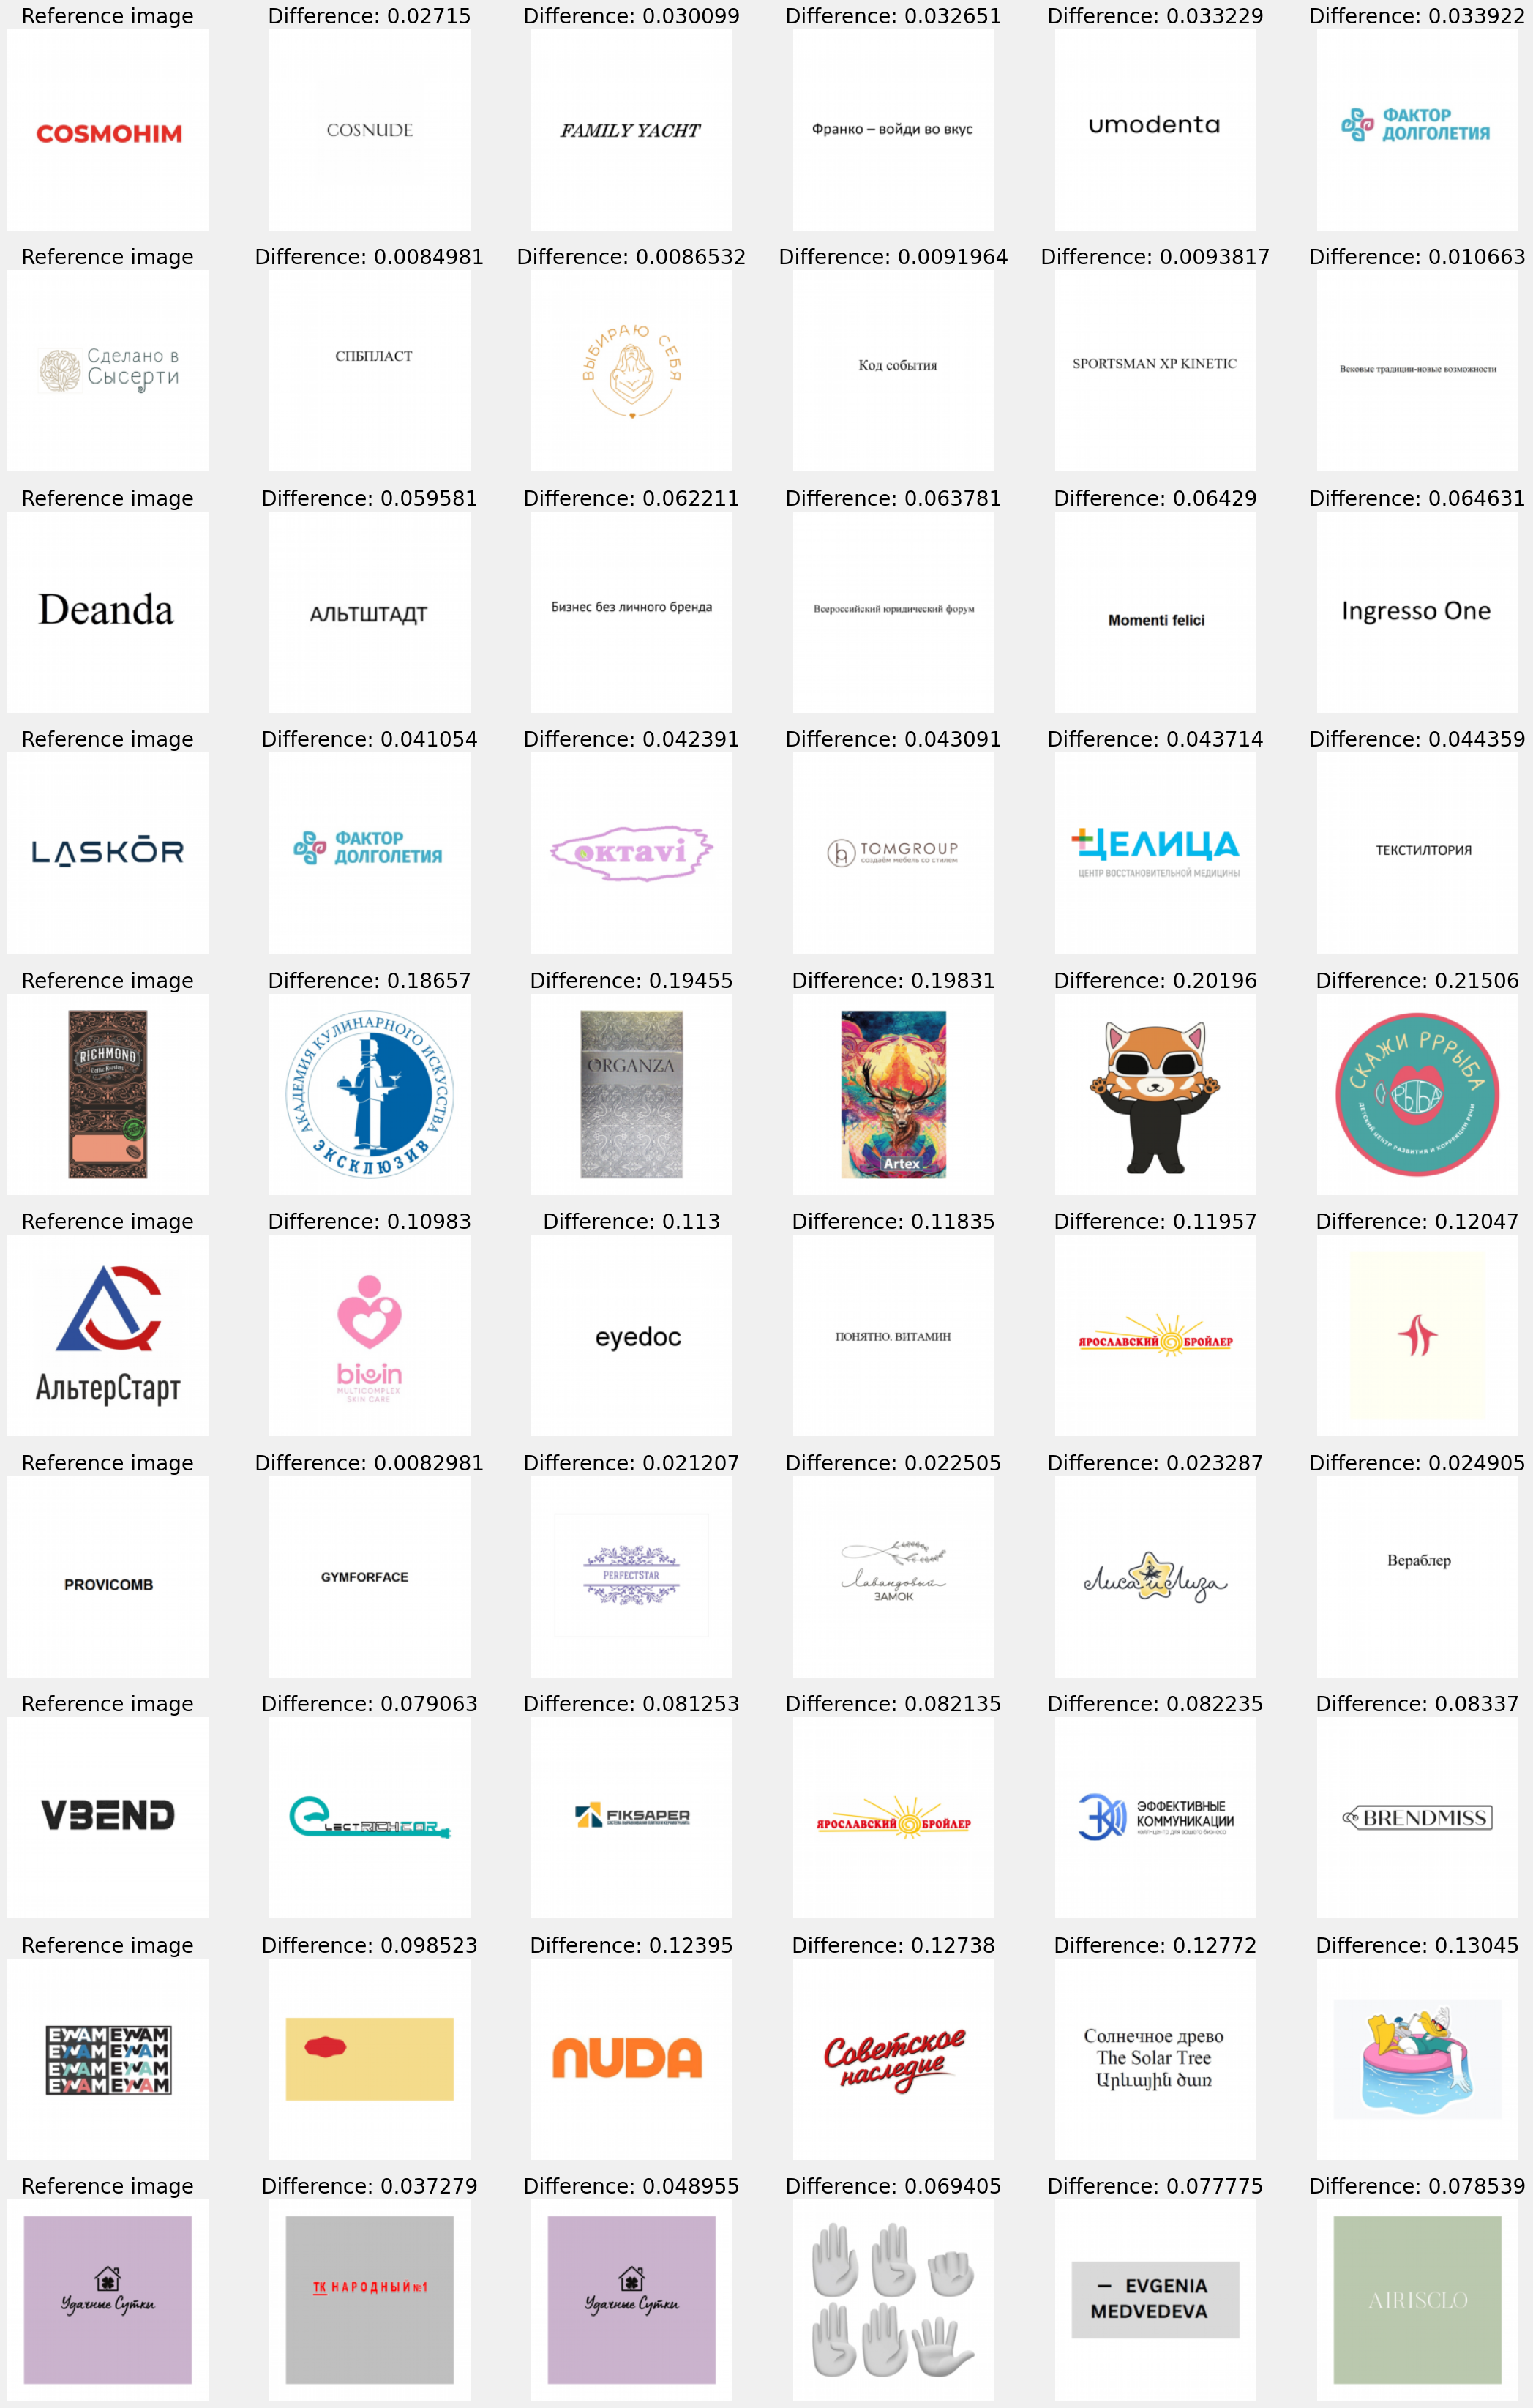

In [36]:
w, h = 6, 10
_, axs = plt.subplots(h, w, figsize=(w * 4, h * 4))

images = load_paths(images_path)

image_paths = []
np.random.shuffle(images)
image_paths.extend(images)

loss_fn = nn.MSELoss()
model.eval()
for i, ax_row in enumerate(axs):
    img_path = image_paths[i]
    img = load_image(img_path)

    encoded = model.encoder(img.unsqueeze(0).to(device)).detach()
    
    losses = []
    paths = []
    for images, img_paths in loader:
        other_enc = model.encoder(images.to(device)).detach()
        losses.extend([loss_fn(encoded, e).cpu() for e in other_enc])
        paths.extend(img_paths)
    assert len(losses) == len(paths)
    top_images = np.argsort(losses)

    for i, ax in enumerate(ax_row):
        if i == 0:
            img = load_image(img_path)
            ax.set_title('Reference image')
        else:
            idx = top_images[i - 1]
            img = load_image(paths[idx])
            loss = losses[idx]
            ax.set_title(f'Difference: {loss:.5}')
        ax.set_axis_off()
        ax.imshow(img.transpose(0,1).transpose(1,2))

plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.00041235474..1.0000004].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.021809937..1.0000004].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.06531189..1.0000004].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.21035458..1.0000005].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.119786955..1.0000004].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0041726464..1.0000004].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.

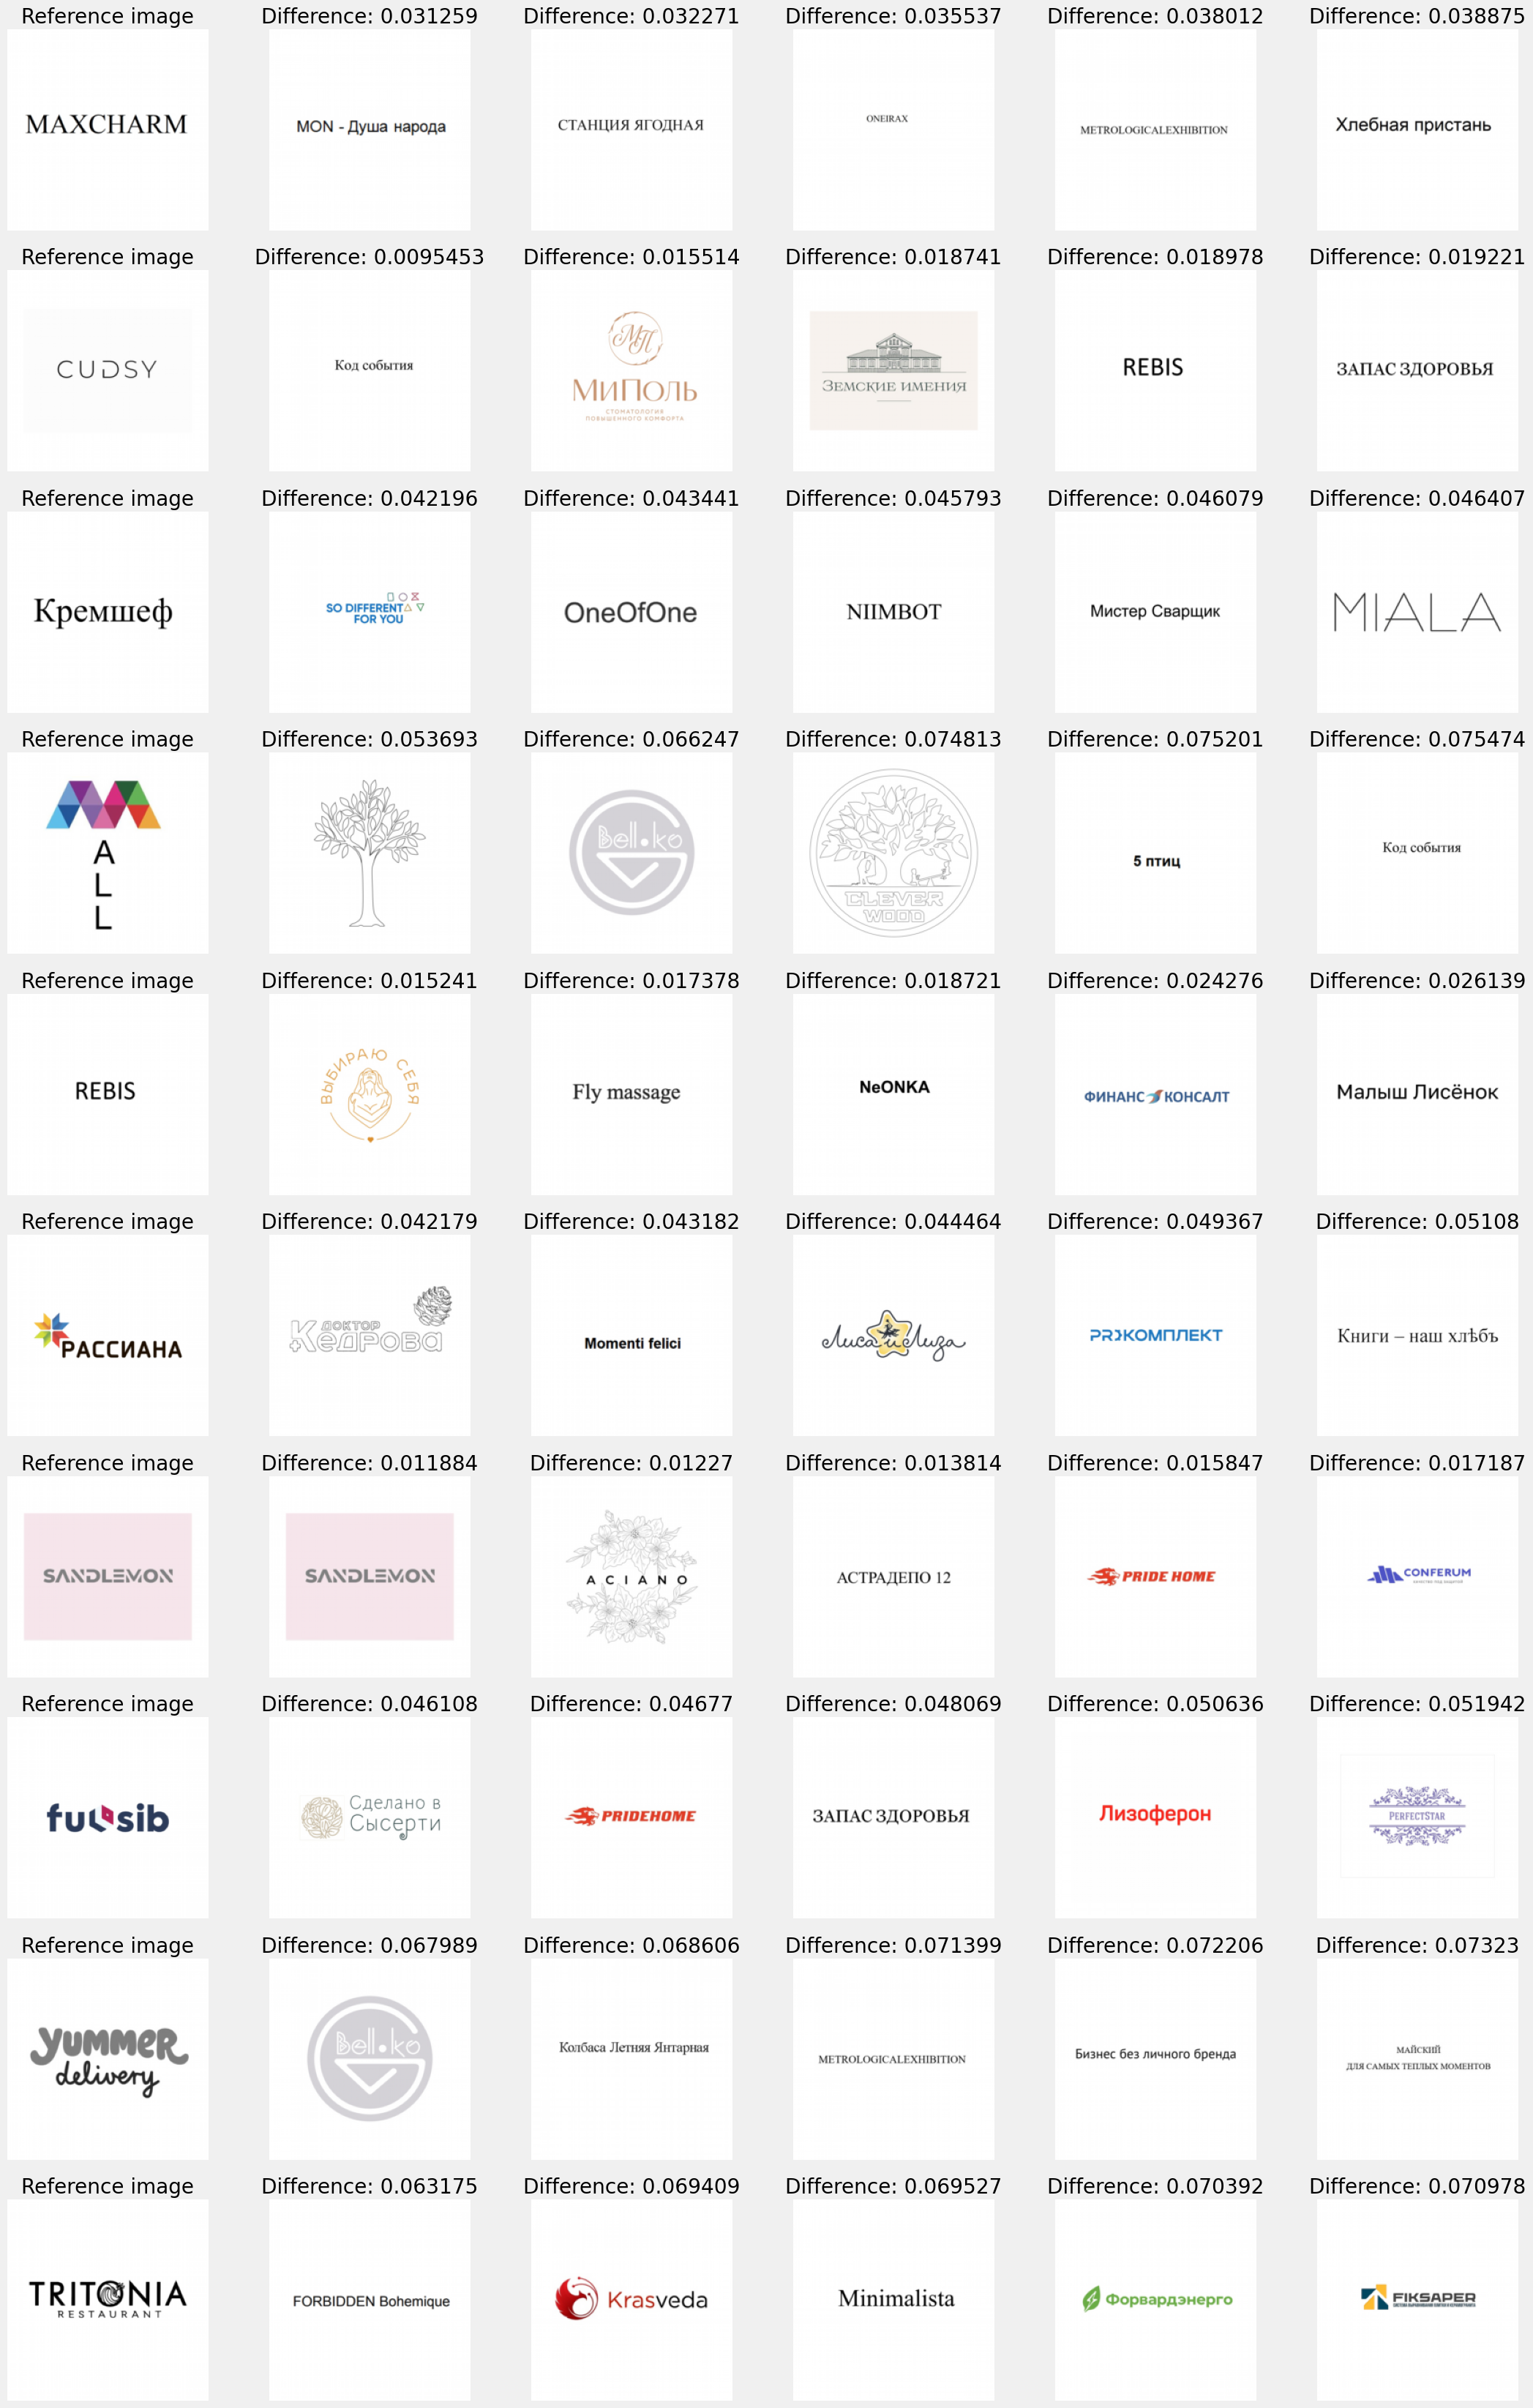

In [37]:
w, h = 6, 10
_, axs = plt.subplots(h, w, figsize=(w * 4, h * 4))

images = load_paths(images_path)

image_paths = []
np.random.shuffle(images)
image_paths.extend(images)

loss_fn = nn.MSELoss()
model.eval()
for i, ax_row in enumerate(axs):
    img_path = image_paths[i]
    img = load_image(img_path)

    encoded = model.encoder(img.unsqueeze(0).to(device)).detach()
    
    losses = []
    paths = []
    for images, img_paths in loader:
        other_enc = model.encoder(images.to(device)).detach()
        losses.extend([loss_fn(encoded, e).cpu() for e in other_enc])
        paths.extend(img_paths)
    assert len(losses) == len(paths)
    top_images = np.argsort(losses)

    for i, ax in enumerate(ax_row):
        if i == 0:
            img = load_image(img_path)
            ax.set_title('Reference image')
        else:
            idx = top_images[i - 1]
            img = load_image(paths[idx])
            loss = losses[idx]
            ax.set_title(f'Difference: {loss:.5}')
        ax.set_axis_off()
        ax.imshow(img.transpose(0,1).transpose(1,2))

plt.show()